# Merge LDA Topic Word Clouds

This notebook crops the center 250×250 square from each cuisine word cloud image, converts them to grayscale, and stitches all 18 images into a compact 3×6 figure for black-and-white paper use.

In [1]:
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

CROP_SIZE = 250
ROWS = 3
COLS = 6
GAP_X = 6
GAP_Y = 6
PADDING = 8
LABEL_HEIGHT = 36
INPUT_FOLDER = Path('figure') / 'lda_topic_wordclouds_multiyear'
OUTPUT_NAME = 'lda_topic_wordclouds_multiyear_grid_3x6.png'

def find_project_root(start=None):
    start_path = Path(start or Path.cwd()).resolve()
    for candidate in [start_path, *start_path.parents]:
        if (candidate / INPUT_FOLDER).exists():
            return candidate
    raise FileNotFoundError(f'Cannot find {INPUT_FOLDER} from {start_path}')

def find_chinese_font():
    candidates = [
        Path(r'C:/Windows/Fonts/msyh.ttc'),
        Path(r'C:/Windows/Fonts/msyh.ttf'),
        Path(r'C:/Windows/Fonts/simhei.ttf'),
        Path(r'C:/Windows/Fonts/simsun.ttc'),
        Path(r'C:/Windows/Fonts/simsun.ttf'),
        Path('/System/Library/Fonts/PingFang.ttc'),
        Path('/System/Library/Fonts/STHeiti Light.ttc'),
        Path('/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc'),
    ]
    for candidate in candidates:
        if candidate.exists():
            return str(candidate)
    return None

def center_crop_square(image, size=CROP_SIZE):
    width, height = image.size
    if width < size or height < size:
        raise ValueError(f'Image too small for {size}x{size} crop: {image.size}')
    left = (width - size) // 2
    top = (height - size) // 2
    return image.crop((left, top, left + size, top + size))

def extract_label(path):
    return path.stem.replace('_词云图', '')

project_root = find_project_root()
input_dir = project_root / INPUT_FOLDER
output_path = input_dir / OUTPUT_NAME
image_paths = sorted(input_dir.glob('*_词云图.png'))

print(f'Project root: {project_root}')
print(f'Found {len(image_paths)} source images')
for path in image_paths:
    print(path.name)

if len(image_paths) != ROWS * COLS:
    raise ValueError(f'Expected {ROWS * COLS} images, got {len(image_paths)}')

font_path = find_chinese_font()
label_font = ImageFont.truetype(font_path, 24) if font_path else ImageFont.load_default()
print(f'Font used: {font_path or "default PIL font"}')

Project root: E:\Codex\Tariff_shock_crime_and_Infrastructure
Found 18 source images
上海菜_词云图.png
东北菜_词云图.png
云贵菜_词云图.png
北京菜_词云图.png
川菜_词云图.png
徽菜_词云图.png
晋菜_词云图.png
江苏菜_词云图.png
江西菜_词云图.png
河北菜_词云图.png
河南菜_词云图.png
浙江菜_词云图.png
清真菜_词云图.png
湖南菜_词云图.png
粤潮菜_词云图.png
鄂菜_词云图.png
闽台菜_词云图.png
鲁菜_词云图.png
Font used: C:\Windows\Fonts\msyh.ttc


Saved merged figure to: E:\Codex\Tariff_shock_crime_and_Infrastructure\figure\lda_topic_wordclouds_multiyear\lda_topic_wordclouds_multiyear_grid_3x6.png


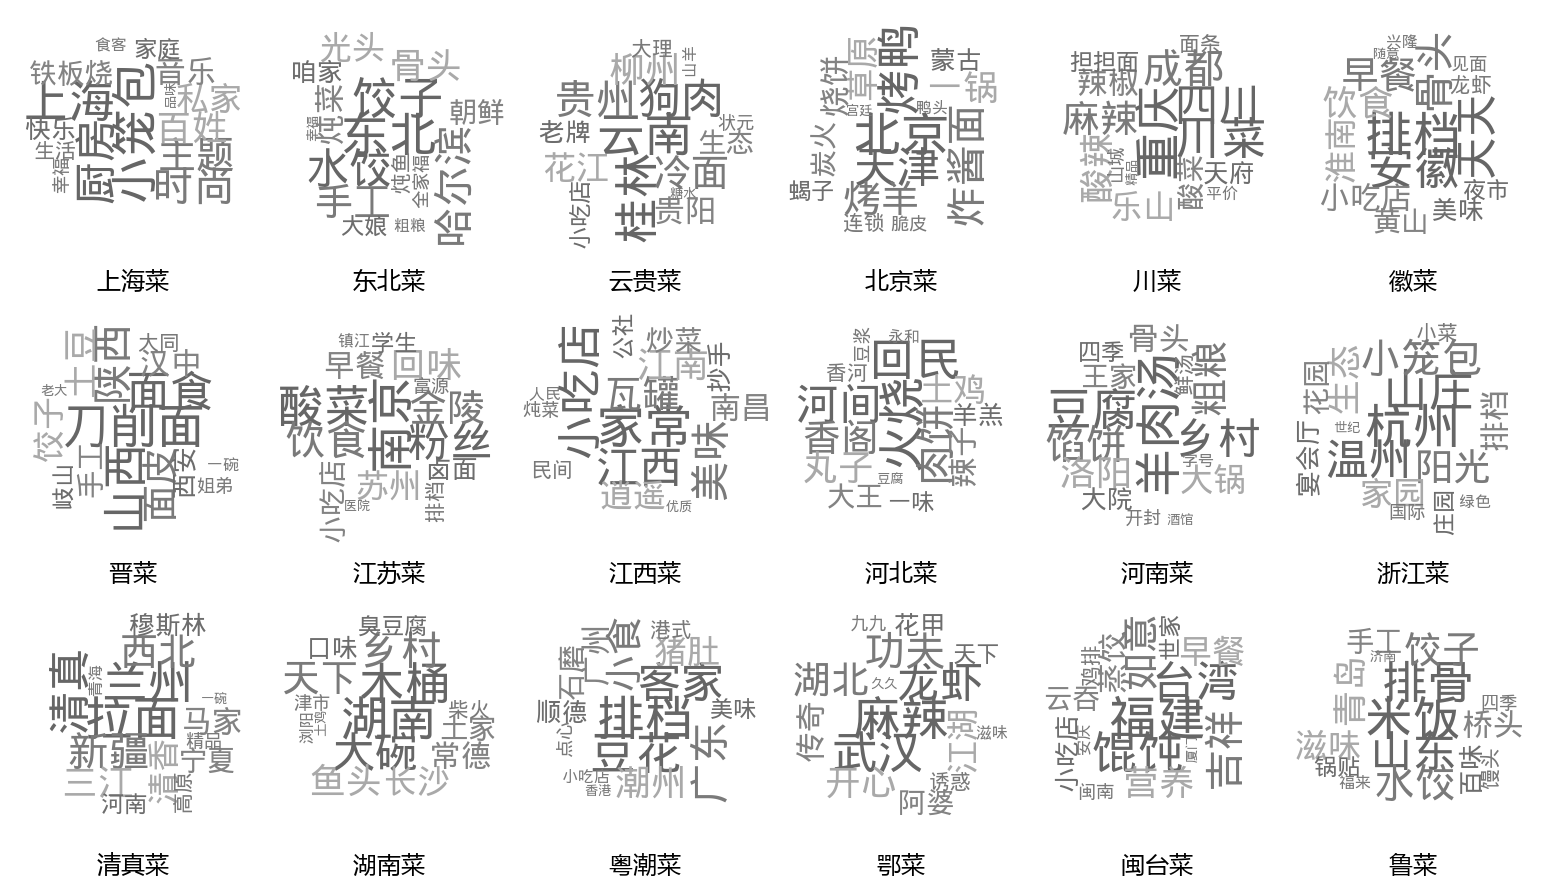

In [3]:
canvas_width = COLS * CROP_SIZE + (COLS - 1) * GAP_X + 2 * PADDING
canvas_height = ROWS * (CROP_SIZE + LABEL_HEIGHT) + (ROWS - 1) * GAP_Y + 2 * PADDING
canvas = Image.new('RGB', (canvas_width, canvas_height), 'white')
draw = ImageDraw.Draw(canvas)

for index, image_path in enumerate(image_paths):
    row = index // COLS
    col = index % COLS
    x0 = PADDING + col * (CROP_SIZE + GAP_X)
    y0 = PADDING + row * (CROP_SIZE + LABEL_HEIGHT + GAP_Y)

    with Image.open(image_path) as image:
        crop = center_crop_square(image.convert('L'))

    canvas.paste(crop, (x0, y0))

    label = extract_label(image_path)
    bbox = draw.textbbox((0, 0), label, font=label_font)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]
    text_x = x0 + (CROP_SIZE - text_width) / 2
    text_y = y0 + CROP_SIZE + (LABEL_HEIGHT - text_height) / 2 - 1
    draw.text((text_x, text_y), label, fill='black', font=label_font)

canvas.save(output_path, optimize=True)
print(f'Saved merged figure to: {output_path}')
display(canvas)